<a href="https://colab.research.google.com/github/theo-mattsa/Spam-Classifier/blob/main/spam_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

In [2]:
# Download latest version
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")

Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.


## Quick Look at the Data Structure

In [4]:
df = pd.read_csv(path + "/spam.csv", encoding='latin')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
# Remove irrelevant columns
df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)

In [7]:
# Rename spam and email text columns
df.rename(columns={'v1': 'label', 'v2': 'text'}, inplace=True)

In [8]:
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Exploratory Data Analysis

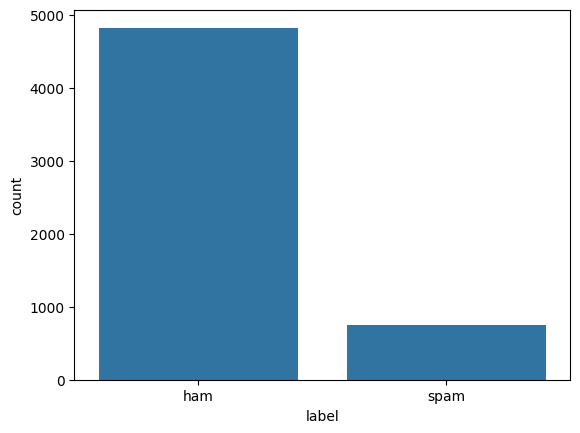

In [9]:
# Target distribution
sns.countplot(x='label', data=df)
plt.show()

In [10]:
# SMS Text Length
df['text_length'] = df['text'].apply(lambda x: len(x))

In [11]:
df['text_length'].describe()

,text_length
count,5572.000000
mean,80.118808
std,59.690841
min,2.000000
25%,36.000000
50%,61.000000
75%,121.000000
max,910.000000


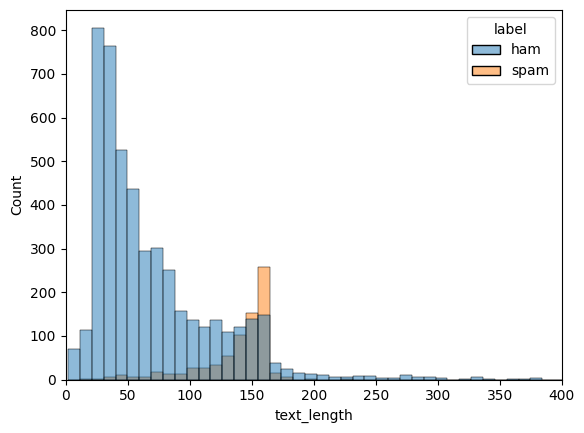

In [12]:
# Histogram (Tex Length)
sns.histplot(data=df, x='text_length', hue='label')
plt.xlim(0, 400)
plt.show()

## Training a model

In [13]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline, make_pipeline

In [14]:
X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [15]:
preprocessing = make_pipeline(CountVectorizer())

In [16]:
pipe = Pipeline([
    ('preprocessing', preprocessing),
    ('classifier', MultinomialNB())
])

In [17]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('countvectorizer', CountVectorizer())])),
                ('classifier', MultinomialNB())])

In [18]:
print(f'Text 1: {X_train[0]}')
print(f'Label 1: {y_train[0]}')
print(f'Prediction: {pipe.predict([X_train[0]])}')

Text 1: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Label 1: ham
Prediction: ['ham']


In [19]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
y_train_pred = cross_val_predict(pipe, X_train, y_train, cv=cv)

In [20]:
confusion_matrix(y_train, y_train_pred)

array([[3847,   12],
       [  46,  552]])

In [21]:
a = classification_report(y_train, y_train_pred)
print(a)

              precision    recall  f1-score   support

         ham       0.99      1.00      0.99      3859
        spam       0.98      0.92      0.95       598

    accuracy                           0.99      4457
   macro avg       0.98      0.96      0.97      4457
weighted avg       0.99      0.99      0.99      4457



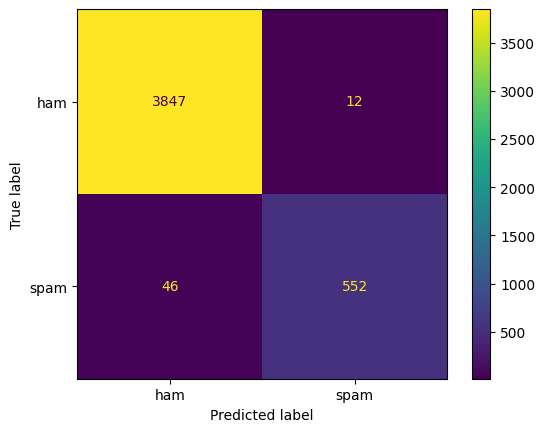

In [22]:
cm = confusion_matrix(y_train, y_train_pred, labels=pipe.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipe.classes_)
disp.plot()